<a href="https://colab.research.google.com/github/temraire117/NLP/blob/main/NLP_week01_%EB%B0%B0%ED%8F%AC%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 자연언어처리 01주차 실습: Google Colab 환경 구축

**배포용 실습 노트북**입니다. 안내된 순서대로 코드를 실행하고, `TODO`로 표시된 부분을 직접 완성하세요.

## 오늘의 목표
1. Google Colab에서 파이썬 실행 환경을 확인한다.
2. 자연어처리 실습에 필요한 라이브러리를 설치한다.
3. 한국어가 그래프에서 정상적으로 출력되도록 설정한다.
4. Kiwi와 KoNLPy를 이용해 한국어 문장을 형태소 단위로 분석한다.
5. GitHub를 활용한 실습 코드 관리 흐름을 이해한다.

> **제출 전 유의사항**: 실행 결과가 보이도록 저장하고, 본인이 작성한 TODO 코드와 짧은 해석을 남기세요.


## 실습 규칙

- 코드는 위에서 아래 순서로 실행합니다.
- 패키지 설치 후 오류가 계속되면 `런타임 → 런타임 다시 시작` 후 설치 셀부터 다시 실행합니다.
- TODO를 해결할 때에는 결과만 복사하지 말고, 사용한 함수가 무엇을 하는지 한 줄로 설명합니다.
- 공개 GitHub 저장소에는 개인정보, 비밀번호, 인증 토큰을 올리지 않습니다.


## 1. 실행 환경 확인

Colab은 웹 브라우저에서 파이썬 코드를 실행할 수 있는 환경입니다. 아래 셀을 실행한 뒤 현재 Python 버전과 운영체제 정보를 확인하세요.


In [1]:
import sys
import platform

print(f"Python version : {sys.version.split()[0]}")
print(f"Platform       : {platform.platform()}")


Python version : 3.13.15
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35


### 체크포인트 1

아래 문장을 Markdown 셀로 추가하여 답하세요.

- 내가 사용하는 Python 버전은 무엇인가?
  - 3.13.15
- 이번 주차에 GPU가 반드시 필요하지 않은 이유는 무엇인가?
  - 머신러닝을 실행하지 않고, 버전 확인 및 라이브러리 설치만 진행하기 때문이다

## 2. 필수 라이브러리 설치

이번 학기에는 다음과 같은 도구를 사용합니다.

- `pandas`, `numpy`: 데이터 처리
- `matplotlib`, `seaborn`: 시각화
- `scikit-learn`: TF-IDF 등 전통 머신러닝
- `kiwipiepy`, `konlpy`: 한국어 형태소 분석
- `transformers`, `datasets`: 후반부 Transformer·LLM 실습

아래 설치 셀을 실행하세요.


In [2]:
!pip -q install -U kiwipiepy konlpy sentencepiece transformers datasets
!pip -q install -U pandas numpy matplotlib seaborn scikit-learn
!pip install --no-cache-dir "numpy>=2.0,<2.3" "pandas==2.2.3" # 버전 강제조정, 런타임 > 세션 재시작

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 274.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 216.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 188.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.3
    Uninstalling numpy-2.5.3:
      Successfully uninstalled numpy-2.5.3
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.5
    Uninstalling pandas-3.0.5:
      Successfully uninstalled pandas-3.0.5


In [3]:
# 설치 확인: TODO를 완성하여 핵심 패키지 2개의 버전을 출력하세요.
import pandas as pd
import numpy as np
import sklearn
import kiwipiepy


print("pandas:", pd.__version__)
# TODO 1. numpy 버전을 출력하세요.
print("numpy:", np.__version__)

# TODO 2. kiwipiepy 버전을 출력하세요.
print("kiwipiepy:", kiwipiepy.__version__)

print("scikit-learn:", sklearn.__version__)


pandas: 2.2.3
numpy: 2.2.6
kiwipiepy: 0.23.2
scikit-learn: 1.9.0


### 체크포인트 2

- `pandas`는 텍스트 데이터를 표 형태로 다룰 때 어떤 역할을 할까요?
  - 텍스트 데이터를 Dataframe으로 저장하여 표 형태로 다룰 수 있다
- `kiwipiepy`는 이후 전처리 단계에서 왜 필요할까요?
  - 문장을 형태소 형태로 분리, 품사를 분석한다
각 질문에 1~2문장으로 답하세요.


## 3. 한글 폰트 설정 및 시각화

텍스트 데이터의 빈도나 길이를 그래프로 표현할 때 한글이 깨지지 않아야 합니다. 아래 셀을 실행해 나눔 폰트를 설치하고 Matplotlib에 적용하세요.


In [4]:
# Colab에서 한글 폰트 설치

!apt-get install -y fonts-nanum
!fc-cache -fv

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

print("한글 폰트 설정 완료")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (15.5 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/s

In [5]:
# matplotlib의 폰트 매니저에 수동으로 추가

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)  # 'NanumGothic' 이 출력되어야 함

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

NanumGothic


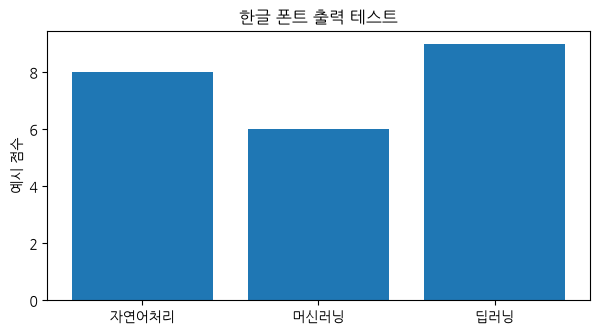

In [6]:
# TODO 3. 아래 범주와 수치를 사용하여 막대그래프를 완성하세요.
categories = ["자연어처리", "머신러닝", "딥러닝"]
values = [8, 6, 9]

plt.figure(figsize=(7, 3.5))
plt.bar(categories, values)  # TODO: categories와 values를 사용하세요.
plt.title("한글 폰트 출력 테스트")
plt.ylabel("예시 점수")
plt.show()


### 체크포인트 3

그래프의 제목과 x축 범주가 한글로 보이는지 확인하세요. 만약 글자가 깨진다면 가능한 원인과 해결 방법을 한 줄로 작성하세요.


## 4. Kiwi로 한국어 형태소 분석하기

한국어는 조사와 어미가 결합하므로 공백만으로 단어를 나누면 의미 있는 분석 단위를 얻기 어렵습니다. Kiwi는 문장을 **형태소**와 **품사 태그**로 분리해 줍니다.


In [7]:
from kiwipiepy import Kiwi

kiwi = Kiwi()
text = "자연어처리 수업에서 한국어 텍스트를 분석합니다."

print("입력 문장:", text)
print("\n[형태소 분석 결과]")
for token in kiwi.tokenize(text):
    print(f"{token.form:10s} | {token.tag}")


입력 문장: 자연어처리 수업에서 한국어 텍스트를 분석합니다.

[형태소 분석 결과]
자연어 처리     | NNP
수업         | NNG
에서         | JKB
한국어        | NNP
텍스트        | NNG
를          | JKO
분석         | NNG
하          | XSV
ᆸ니다        | EF
.          | SF


In [14]:
# TODO 4. 위 문장에서 명사 태그(N으로 시작하는 품사)만 추출하세요.
# 힌트: token.tag.startswith("N")

nouns = []
for token in kiwi.tokenize(text):
  if(token.tag.startswith("N")):
    nouns.append(token.form)

print("명사:", nouns)


명사: ['자연어 처리', '수업', '한국어', '텍스트', '분석']


### 체크포인트 4

출력된 형태소 중 하나를 골라 **형태소 / 품사 태그 / 해당 품사의 의미**를 작성하세요.

`를 / JKO / 목적격 조사`


## 5. KoNLPy의 Okt 형태소 분석기 사용하기

KoNLPy는 여러 한국어 형태소 분석기를 파이썬에서 사용할 수 있게 해주는 라이브러리입니다. 아래에서 Okt의 형태소 분석 결과를 Kiwi의 결과와 비교합니다.


In [9]:
from konlpy.tag import Okt

okt = Okt()
text = "자연어처리 수업에서 한국어 텍스트를 분석합니다."

print("형태소:", okt.morphs(text))
print("명사  :", okt.nouns(text))
print("품사  :", okt.pos(text))


형태소: ['자연어', '처리', '수업', '에서', '한국어', '텍스트', '를', '분석', '합니다', '.']
명사  : ['자연어', '처리', '수업', '한국어', '텍스트', '분석']
품사  : [('자연어', 'Noun'), ('처리', 'Noun'), ('수업', 'Noun'), ('에서', 'Josa'), ('한국어', 'Noun'), ('텍스트', 'Noun'), ('를', 'Josa'), ('분석', 'Noun'), ('합니다', 'Verb'), ('.', 'Punctuation')]


In [10]:
# TODO 5. 본인이 작성한 문장으로 형태소 분석을 수행하세요.
my_sentence = "다람쥐 헌 챗바퀴에 타고파"

print("문장:", my_sentence)
print("Kiwi:", [(t.form, t.tag) for t in kiwi.tokenize(my_sentence)])
print("Okt :", okt.pos(my_sentence))  # TODO: Okt 품사 분석 결과를 출력하세요.


문장: 다람쥐 헌 챗바퀴에 타고파
Kiwi: [('다람쥐', 'NNG'), ('헌', 'MM'), ('챗바퀴', 'NNG'), ('에', 'JKB'), ('타', 'VV'), ('어', 'EC'), ('고프', 'VA'), ('어', 'EF')]
Okt : [('다람쥐', 'Noun'), ('헌', 'Noun'), ('챗', 'Noun'), ('바퀴', 'Noun'), ('에', 'Josa'), ('타고', 'Noun'), ('파', 'Noun')]


### 비교 질문

Kiwi와 Okt의 결과에서 토큰 분리 또는 품사 태그가 다른 사례를 한 가지 찾아 적으세요. 완전히 같아도 괜찮지만, 그 경우에는 사용한 문장과 결과를 기록하세요.

단어: 다람쥐

Kiwi:NNG

Okt: Noun



## 6. 간단한 텍스트 정제 맛보기

본격적인 텍스트 전처리는 이후 주차에서 다룹니다. 여기서는 특수문자 제거와 공백 정리만 간단히 체험합니다.


In [11]:
import re

sample = "NLP 실습은 재미있습니다! 2026년에도 꾸준히 학습해 봅시다. :)"

# TODO 6. 한글, 영문, 숫자, 공백을 제외한 문자를 공백으로 바꾸세요.
# 힌트: re.sub(패턴, 바꿀문자열, 대상문자열)
cleaned = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", sample)

# TODO 7. 연속된 공백을 하나로 정리하고 양쪽 공백을 제거하세요.
cleaned = re.sub(r"\s+", " ", cleaned).strip()

print("원문      :", sample)
print("정제 결과 :", cleaned)
print("토큰      :", cleaned.lower().split())


원문      : NLP 실습은 재미있습니다! 2026년에도 꾸준히 학습해 봅시다. :)
정제 결과 : NLP 실습은 재미있습니다 2026년에도 꾸준히 학습해 봅시다
토큰      : ['nlp', '실습은', '재미있습니다', '2026년에도', '꾸준히', '학습해', '봅시다']


### 체크포인트 5

특수문자를 모두 지우는 것이 언제나 좋은 전처리 방법은 아닙니다. 이모지, 해시태그, 느낌표 중 하나를 골라 **삭제하면 잃을 수 있는 정보**를 한 문장으로 설명하세요.

느낌표를 삭제하면 화자의 감정이나 문장의 의도를 잃을 수 있다.

## 7. GitHub 코드 관리 준비

수업에서 작성한 노트북과 프로젝트 코드는 GitHub 저장소에 체계적으로 기록합니다. 아래는 기본 흐름이며, 실제 저장소 주소와 개인정보는 본인이 설정한 뒤 사용하세요.


In [27]:
# Git 사용자 정보 설정 예시
# 아래 주석을 해제한 뒤 본인 정보로 수정해 실행하세요.
!git config --global user.name "Acsard"
!git config --global user.email "temraire117@gmail.com"

# 현재 설정 확인
!git config --global --list


user.name=Acsard
user.email=temraire117@gmail.com


In [25]:
# 저장소 생성 후 기본 작업 흐름 예시
#!git init
#!git add .
#!git commit -m "chore: initialize NLP practice environment"
#!git branch -M main
#!git remote set-url origin https://github.com/Acsard/NLP_week01.git
#!git push -u origin main


Reinitialized existing Git repository in /content/.git/
On branch main
nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


## 제출 과제: 나의 환경 점검 기록

아래를 모두 완료한 뒤 노트북을 저장하고, 수업에서 안내한 방식으로 제출합니다.

- [ ] TODO 1~7을 모두 완성하고 실행했다.
- [ ] 한글 막대그래프가 정상 출력되도록 했다.
- [ ] 본인이 만든 한국어 문장을 Kiwi와 Okt로 분석했다.
- [ ] Kiwi와 Okt 결과 차이 또는 관찰 내용을 기록했다.
- [ ] 텍스트 정제 결과와 특수문자 처리에 대한 의견을 작성했다.
- [ ] GitHub 코드 관리 시 민감정보를 공개하지 않는 이유를 작성했다.

> **제출물**: 실행 결과가 포함된 `.ipynb` 파일 또는 강의에서 지정한 GitHub 저장소 링크


## 다음 주 예고

### 2주차: 자연어와 텍스트 데이터 이해

다음 실습에서는 자연어와 텍스트 데이터의 특성을 이해하고, 정형·반정형·비정형 데이터의 차이, UTF-8 인코딩과 한글 정규화(NFC/NFD), 데이터 품질·윤리, 기초 텍스트 탐색 분석(EDA)을 다룹니다.
이후 주차에서 토큰화·불용어 제거·어간 추출 등 한국어 텍스트 전처리를 본격적으로 학습합니다.

### 미리 준비할 것

-  GitHub 계정 생성 완료
-  Colab 환경 설정 완료
-  1주차 과제 제출 완료
